# DeepEval Evaluation Report - Worked Example

This notebook demonstrates the final report structure using synthetic DeepEval-like outputs for FT and RAG across Expert and Operational scenarios.

## Purpose
Use this notebook as the gold standard example for the final report once real endpoint exports are available.

## Data contract and assumptions

The example below mimics the CSVs returned by the admin evaluation endpoint and keeps the same analysis structure you will use with the real files.

### Checklist
- [x] The notebook uses DeepEval-style output columns.
- [x] The example includes FT and RAG runs.
- [x] The example covers Expert and Operational scenarios.
- [x] The notebook includes a latency column for trade-off analysis.

## DeepEval endpoint schema

This example is aligned with the admin evaluation endpoint output shape.

### Expected fields
- `Question`
- `Actual Answer`
- `Expected Output`
- `* Score` metric columns
- `* Reason` metric columns
- `latency_s` for trade-off analysis

### Checklist
- [x] The example matches the endpoint export contract.
- [x] The notebook remains usable with real CSV downloads.
- [x] Metric reasons are kept available for qualitative review.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)

ENDPOINT_CORE_COLUMNS = [
    'Question',
    'Actual Answer',
    'Expected Output',
]

METRIC_SCORE_COLUMNS = [
    'Correctness Score',
    'Faithfulness Score',
    'Answer Relevancy Score',
    'ContextualPrecision Score',
    'ContextualRecall Score',
    'ContextualRelevancy Score',
]

METRIC_REASON_COLUMNS = [
    'Correctness Reason',
    'Faithfulness Reason',
    'Answer Relevancy Reason',
    'ContextualPrecision Reason',
    'ContextualRecall Reason',
    'ContextualRelevancy Reason',
]

def normalize_endpoint_export(df):
    if df.empty:
        return df
    rename_map = {
        'question': 'Question',
        'query': 'Question',
        'actual_answer': 'Actual Answer',
        'answer': 'Actual Answer',
        'result': 'Actual Answer',
        'expected_output': 'Expected Output',
        'reference': 'Expected Output',
        'latency': 'latency_s',
    }
    normalized = df.rename(columns={source: target for source, target in rename_map.items() if source in df.columns})
    return normalized

def validate_endpoint_export(df):
    required_columns = ENDPOINT_CORE_COLUMNS + METRIC_SCORE_COLUMNS
    missing_columns = [column for column in required_columns if column not in df.columns]
    return {
        'valid': not missing_columns,
        'missing': missing_columns,
    }

def detect_metric_columns(df):
    return [column for column in df.columns if column.endswith(' Score')] if not df.empty else []

def build_summary_table(df):
    metric_columns = detect_metric_columns(df)
    group_columns = ['system_type', 'scenario']
    numeric_columns = metric_columns + (['latency_s'] if 'latency_s' in df.columns else [])
    return df.groupby(group_columns, as_index=False)[numeric_columns].mean()

def build_wins_table(summary_df, metric_columns):
    rows = []
    for scenario_name in summary_df['scenario'].unique():
        subset = summary_df[summary_df['scenario'] == scenario_name]
        for metric in metric_columns:
            best_row = subset.loc[subset[metric].idxmax()]
            rows.append({
                'scenario': scenario_name,
                'metric': metric,
                'winner': best_row['system_type'],
                'score': best_row[metric],
            })
    return pd.DataFrame(rows)

def build_reason_table(df, max_rows=8):
    reason_columns = [column for column in df.columns if column.endswith(' Reason')]
    if df.empty or not reason_columns:
        return pd.DataFrame()
    preview_columns = ['system_type', 'scenario', 'Question'] + reason_columns
    return df[preview_columns].head(max_rows)

def plot_metric_bars(summary_df, metric_columns):
    melted = summary_df.melt(id_vars=['system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    g = sns.catplot(
        data=melted,
        kind='bar',
        x='metric',
        y='score',
        hue='system_type',
        col='scenario',
        palette='Set2',
        height=4.5,
        aspect=1.3,
        sharey=True,
    )
    g.set_xticklabels(rotation=45, ha='right')
    g.set_titles('{col_name}')
    g.fig.suptitle('DeepEval metric comparison by system and scenario', y=1.05)
    plt.show()

def plot_metric_distributions(df, metric_columns):
    melted = df.melt(id_vars=['system_type', 'scenario'], value_vars=metric_columns, var_name='metric', value_name='score')
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=melted, x='metric', y='score', hue='system_type', ax=ax, palette='Set3')
    ax.set_title('Score dispersion by metric')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

def plot_latency_scatter(df):
    metric_columns = detect_metric_columns(df)
    if df.empty or 'latency_s' not in df.columns or not metric_columns:
        print('Latency is not available in the current dataset.')
        return
    df_plot = df.copy()
    df_plot['quality_mean'] = df_plot[metric_columns].mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.scatterplot(data=df_plot, x='latency_s', y='quality_mean', hue='system_type', style='scenario', s=90, ax=ax)
    ax.set_title('Latency vs average quality')
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Average quality score')
    plt.tight_layout()
    plt.show()

## 1. Load and normalize evaluation outputs

The synthetic dataset below mirrors the merged endpoint exports you will eventually load from CSV files.

### Checklist
- [x] Four runs are present: FT/RAG x Expert/Operational.
- [x] Every run has question, answer, expected output, and metric columns.
- [x] Latency is included for trade-off analysis.
- [x] The structure can be replaced with real endpoint exports without changing the analysis code.

In [2]:
scenario_bank = {
    'Expert': [
        {
            'question': 'How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?',
            'expected_output': 'Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.',
            'rag_answer': 'Check the SQL Server DMVs, especially sys.dm_exec_requests joined with sys.dm_exec_sql_text, and inspect the blocking session tree before taking action.',
            'ft_answer': 'Use sys.dm_exec_requests with sys.dm_exec_sql_text to identify the blocking chain and the blocking session quickly.',
        },
        {
            'question': 'What validation is required before issuing KILL on a long-running transaction?',
            'expected_output': 'Verify the transaction state in sys.dm_tran_active_transactions before terminating it.',
            'rag_answer': 'Confirm the transaction status in sys.dm_tran_active_transactions and review the business impact before issuing KILL.',
            'ft_answer': 'Check sys.dm_tran_active_transactions first, then kill only if the transaction is confirmed stale or orphaned.',
        },
        {
            'question': 'How is a suspended secondary replica reinitialized after logical corruption?',
            'expected_output': 'Remove the secondary database, restore from a log backup with NORECOVERY, and resynchronize the replica.',
            'rag_answer': 'Rebuild the secondary by restoring the database with NORECOVERY after a fresh log backup and then resume the availability group synchronization.',
            'ft_answer': 'Drop the secondary copy, restore it with NORECOVERY, and resume synchronization from the primary log backup.',
        },
        {
            'question': 'How do you distinguish a nearby Wi-Fi network from a Rogue AP in Windows?',
            'expected_output': 'Run netsh wlan show networks mode=bssid and inspect the suspicious BSSID values.',
            'rag_answer': 'Use netsh wlan show networks mode=bssid to inspect each BSSID and compare it against the corporate network inventory.',
            'ft_answer': 'Run netsh wlan show networks mode=bssid and flag the BSSID that does not match the expected SSID inventory.',
        },
    ],
    'Operational': [
        {
            'question': 'What PowerShell command blocks a user from Microsoft 365 immediately during a security incident?',
            'expected_output': 'Set-MsolUser -UserPrincipalName <user> -BlockCredential $true.',
            'rag_answer': 'Use Set-MsolUser -UserPrincipalName <user> -BlockCredential $true and verify that the account is no longer able to authenticate.',
            'ft_answer': 'Run Set-MsolUser -UserPrincipalName <user> -BlockCredential $true to block access immediately.',
        },
        {
            'question': 'What should support do if the work profile PIN is locked on a managed mobile device?',
            'expected_output': 'Reset the work profile passcode from the MDM console for the affected device.',
            'rag_answer': 'Open the MDM console, locate the device, and use the passcode reset action for the work profile so the user can enroll again.',
            'ft_answer': 'Use the MDM console to reset the work profile passcode and restore access for the managed device.',
        },
        {
            'question': 'How do you clean a stuck Windows print queue from the command line?',
            'expected_output': 'Stop the spooler service, clear the printer spool folder, and restart the service.',
            'rag_answer': 'Stop the spooler service, clear the printer spool folder, and restart the service after confirming the queue is empty.',
            'ft_answer': 'Use net stop spooler, clear the spool folder, and then run net start spooler to restore printing.',
        },
        {
            'question': 'What should be checked when the Authenticator code is repeatedly rejected?',
            'expected_output': 'Verify automatic time and resynchronize time in the Authenticator app.',
            'rag_answer': 'Check automatic time on the device and resynchronize time in Authenticator because a clock drift breaks TOTP validation.',
            'ft_answer': 'Enable automatic time on the device and resync the Authenticator clock to fix the rejected code.',
        },
    ],
}

def build_metric_reasons(system_type, scenario):
    if system_type == 'RAG':
        return {
            'Correctness Reason': f'In {scenario}, the answer stays technically grounded and complete, although it may be slightly more verbose.',
            'Faithfulness Reason': f'In {scenario}, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.',
            'Answer Relevancy Reason': f'In {scenario}, the response remains directly on topic and addresses the user request with supporting context.',
            'ContextualPrecision Reason': f'In {scenario}, the answer prioritizes the most relevant retrieved evidence for the task.',
            'ContextualRecall Reason': f'In {scenario}, the answer covers most of the useful supporting context available from retrieval.',
            'ContextualRelevancy Reason': f'In {scenario}, the retrieved context is clearly related to the question and reinforces the response.',
        }
    return {
        'Correctness Reason': f'In {scenario}, the answer is concise, actionable, and aligned with the expected operational procedure.',
        'Faithfulness Reason': f'In {scenario}, the answer is shorter and less context-heavy, so grounding is good but less explicit than RAG.',
        'Answer Relevancy Reason': f'In {scenario}, the answer stays tightly focused on the requested action and avoids unnecessary detail.',
        'ContextualPrecision Reason': f'In {scenario}, the answer focuses on the most operationally relevant steps, but it does not surface as much retrieved evidence as RAG.',
        'ContextualRecall Reason': f'In {scenario}, the answer covers the core action steps but leaves out some evidence-rich detail.',
        'ContextualRelevancy Reason': f'In {scenario}, the response is relevant to the operational case, though it relies more on concise instruction than on broader context.',
    }

profiles = {
    ('RAG', 'Expert'): {
        'Correctness Score': [0.81, 0.79, 0.80, 0.82],
        'Faithfulness Score': [0.93, 0.92, 0.94, 0.91],
        'Answer Relevancy Score': [0.86, 0.84, 0.85, 0.87],
        'ContextualPrecision Score': [0.91, 0.90, 0.92, 0.89],
        'ContextualRecall Score': [0.90, 0.88, 0.91, 0.89],
        'ContextualRelevancy Score': [0.92, 0.90, 0.93, 0.91],
        'latency_s': [4.3, 4.5, 4.1, 4.4],
    },
    ('FT', 'Expert'): {
        'Correctness Score': [0.86, 0.85, 0.87, 0.84],
        'Faithfulness Score': [0.87, 0.86, 0.88, 0.85],
        'Answer Relevancy Score': [0.88, 0.87, 0.89, 0.86],
        'ContextualPrecision Score': [0.84, 0.83, 0.85, 0.82],
        'ContextualRecall Score': [0.82, 0.81, 0.83, 0.80],
        'ContextualRelevancy Score': [0.83, 0.82, 0.84, 0.81],
        'latency_s': [2.1, 2.0, 2.2, 2.1],
    },
    ('RAG', 'Operational'): {
        'Correctness Score': [0.83, 0.82, 0.81, 0.84],
        'Faithfulness Score': [0.90, 0.89, 0.91, 0.88],
        'Answer Relevancy Score': [0.85, 0.84, 0.83, 0.86],
        'ContextualPrecision Score': [0.87, 0.86, 0.85, 0.88],
        'ContextualRecall Score': [0.86, 0.85, 0.84, 0.87],
        'ContextualRelevancy Score': [0.88, 0.87, 0.86, 0.89],
        'latency_s': [4.0, 4.1, 3.9, 4.2],
    },
    ('FT', 'Operational'): {
        'Correctness Score': [0.89, 0.88, 0.90, 0.87],
        'Faithfulness Score': [0.85, 0.84, 0.86, 0.83],
        'Answer Relevancy Score': [0.91, 0.90, 0.92, 0.89],
        'ContextualPrecision Score': [0.82, 0.81, 0.83, 0.80],
        'ContextualRecall Score': [0.80, 0.79, 0.81, 0.78],
        'ContextualRelevancy Score': [0.81, 0.80, 0.82, 0.79],
        'latency_s': [1.8, 1.7, 1.9, 1.8],
    },
}

rows = []
for (system_type, scenario), profile in profiles.items():
    items = scenario_bank[scenario]
    reason_templates = build_metric_reasons(system_type, scenario)
    for index, item in enumerate(items):
        rows.append({
            'run_name': f'{system_type}-{scenario}',
            'system_type': system_type,
            'scenario': scenario,
            'sample_id': index + 1,
            'Question': item['question'],
            'Actual Answer': item[f'{system_type.lower()}_answer'],
            'Expected Output': item['expected_output'],
            'Correctness Score': profile['Correctness Score'][index],
            'Correctness Reason': reason_templates['Correctness Reason'],
            'Faithfulness Score': profile['Faithfulness Score'][index],
            'Faithfulness Reason': reason_templates['Faithfulness Reason'],
            'Answer Relevancy Score': profile['Answer Relevancy Score'][index],
            'Answer Relevancy Reason': reason_templates['Answer Relevancy Reason'],
            'ContextualPrecision Score': profile['ContextualPrecision Score'][index],
            'ContextualPrecision Reason': reason_templates['ContextualPrecision Reason'],
            'ContextualRecall Score': profile['ContextualRecall Score'][index],
            'ContextualRecall Reason': reason_templates['ContextualRecall Reason'],
            'ContextualRelevancy Score': profile['ContextualRelevancy Score'][index],
            'ContextualRelevancy Reason': reason_templates['ContextualRelevancy Reason'],
            'latency_s': profile['latency_s'][index],
        })

results_df = pd.DataFrame(rows)
results_df = normalize_endpoint_export(results_df)
schema_status = validate_endpoint_export(results_df)
print(schema_status)
display(results_df.head(8))

{'valid': True, 'missing': []}


,run_name,system_type,scenario,sample_id,Question,Actual Answer,Expected Output,Correctness Score,Correctness Reason,Faithfulness Score,Faithfulness Reason,Answer Relevancy Score,Answer Relevancy Reason,ContextualPrecision Score,ContextualPrecision Reason,ContextualRecall Score,ContextualRecall Reason,ContextualRelevancy Score,ContextualRelevancy Reason,latency_s
0,RAG-Expert,RAG,Expert,1,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"Check the SQL Server DMVs, especially sys.dm_exec_requests joined with sys.dm_exec_sql_text, and inspect the blockin...",Query sys.dm_exec_requests and join with sys.dm_exec_sql_text to trace the lock chain.,0.81,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.",0.93,"In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.",0.86,"In Expert, the response remains directly on topic and addresses the user request with supporting context.",0.91,"In Expert, the answer prioritizes the most relevant retrieved evidence for the task.",0.90,"In Expert, the answer covers most of the useful supporting context available from retrieval.",0.92,"In Expert, the retrieved context is clearly related to the question and reinforces the response.",4.3
1,RAG-Expert,RAG,Expert,2,What validation is required before issuing KILL on a long-running transaction?,Confirm the transaction status in sys.dm_tran_active_transactions and review the business impact before issuing KILL.,Verify the transaction state in sys.dm_tran_active_transactions before terminating it.,0.79,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.",0.92,"In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.",0.84,"In Expert, the response remains directly on topic and addresses the user request with supporting context.",0.90,"In Expert, the answer prioritizes the most relevant retrieved evidence for the task.",0.88,"In Expert, the answer covers most of the useful supporting context available from retrieval.",0.90,"In Expert, the retrieved context is clearly related to the question and reinforces the response.",4.5
2,RAG-Expert,RAG,Expert,3,How is a suspended secondary replica reinitialized after logical corruption?,Rebuild the secondary by restoring the database with NORECOVERY after a fresh log backup and then resume the availab...,"Remove the secondary database, restore from a log backup with NORECOVERY, and resynchronize the replica.",0.80,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.",0.94,"In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.",0.85,"In Expert, the response remains directly on topic and addresses the user request with supporting context.",0.92,"In Expert, the answer prioritizes the most relevant retrieved evidence for the task.",0.91,"In Expert, the answer covers most of the useful supporting context available from retrieval.",0.93,"In Expert, the retrieved context is clearly related to the question and reinforces the response.",4.1
3,RAG-Expert,RAG,Expert,4,How do you distinguish a nearby Wi-Fi network from a Rogue AP in Windows?,Use netsh wlan show networks mode=bssid to inspect each BSSID and compare it against the corporate network inventory.,Run netsh wlan show networks mode=bssid and inspect the suspicious BSSID values.,0.82,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.",0.91,"In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.",0.87,"In Expert, the response remains directly on topic and addresses the user request with supporting context.",0.89,"In Expert, the answer prioritizes the most relevant retrieved evidence for the task.",0.89,"In Expert, the answer covers most of th

## 2. Validate schema and metric coverage

The example uses the same core validation rules that you will apply to the real endpoint exports.

### Checklist
- [x] The required columns are present.
- [x] Metric columns are numeric and bounded.
- [x] The dataset is sorted and reproducible.
- [x] The schema can be swapped for real CSV exports without changing the reporting logic.

In [3]:
required_columns = ["Question", "Actual Answer", "Expected Output", "system_type", "scenario", "latency_s"]
missing_columns = [column for column in required_columns if column not in results_df.columns]
print({"missing_columns": missing_columns, "row_count": len(results_df)})

metric_columns = detect_metric_columns(results_df)
summary_df = build_summary_table(results_df)
wins_df = build_wins_table(summary_df, metric_columns)

display(summary_df)
display(wins_df)

{'missing_columns': [], 'row_count': 16}


,system_type,scenario,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,FT,Expert,0.855,0.865,0.875,0.835,0.815,0.825,2.100
1,FT,Operational,0.885,0.845,0.905,0.815,0.795,0.805,1.800
2,RAG,Expert,0.805,0.925,0.855,0.905,0.895,0.915,4.325
3,RAG,Operational,0.825,0.895,0.845,0.865,0.855,0.875,4.050


,scenario,metric,winner,score
0,Expert,Correctness Score,FT,0.855
1,Expert,Faithfulness Score,RAG,0.925
2,Expert,Answer Relevancy Score,FT,0.875
3,Expert,ContextualPrecision Score,RAG,0.905
4,Expert,ContextualRecall Score,RAG,0.895
5,Expert,ContextualRelevancy Score,RAG,0.915
6,Operational,Correctness Score,FT,0.885
7,Operational,Faithfulness Score,RAG,0.895
8,Operational,Answer Relevancy Score,FT,0.905
9,Operational,ContextualPrecision Score,RAG,0.865


## 3. Metric reason review

The endpoint export includes `* Reason` columns. This section shows how to review the qualitative evidence behind the scores.

### Checklist
- [x] Metric reasons are available for both FT and RAG.
- [x] The report can quote reasons directly when discussing trade-offs.
- [x] The analysis keeps quantitative and qualitative evidence together.

In [4]:
reason_snapshot_df = build_reason_table(results_df)

if reason_snapshot_df.empty:
    print('No metric reasons are available in the current dataset.')
else:
    display(reason_snapshot_df)

    scenario_reason_summary = (
        reason_snapshot_df.groupby(['system_type', 'scenario'], as_index=False)
        .first()
    )
    display(scenario_reason_summary)

,system_type,scenario,Question,Correctness Reason,Faithfulness Reason,Answer Relevancy Reason,ContextualPrecision Reason,ContextualRecall Reason,ContextualRelevancy Reason
0,RAG,Expert,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.","In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.","In Expert, the response remains directly on topic and addresses the user request with supporting context.","In Expert, the answer prioritizes the most relevant retrieved evidence for the task.","In Expert, the answer covers most of the useful supporting context available from retrieval.","In Expert, the retrieved context is clearly related to the question and reinforces the response."
1,RAG,Expert,What validation is required before issuing KILL on a long-running transaction?,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.","In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.","In Expert, the response remains directly on topic and addresses the user request with supporting context.","In Expert, the answer prioritizes the most relevant retrieved evidence for the task.","In Expert, the answer covers most of the useful supporting context available from retrieval.","In Expert, the retrieved context is clearly related to the question and reinforces the response."
2,RAG,Expert,How is a suspended secondary replica reinitialized after logical corruption?,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.","In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.","In Expert, the response remains directly on topic and addresses the user request with supporting context.","In Expert, the answer prioritizes the most relevant retrieved evidence for the task.","In Expert, the answer covers most of the useful supporting context available from retrieval.","In Expert, the retrieved context is clearly related to the question and reinforces the response."
3,RAG,Expert,How do you distinguish a nearby Wi-Fi network from a Rogue AP in Windows?,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.","In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.","In Expert, the response remains directly on topic and addresses the user request with supporting context.","In Expert, the answer prioritizes the most relevant retrieved evidence for the task.","In Expert, the answer covers most of the useful supporting context available from retrieval.","In Expert, the retrieved context is clearly related to the question and reinforces the response."
4,FT,Expert,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"In Expert, the answer is concise, actionable, and aligned with the expected operational procedure.","In Expert, the answer is shorter and less context-heavy, so grounding is good but less explicit than RAG.","In Expert, the answer stays tightly focused on the requested action and avoids unnecessary detail.","In Expert, the answer focuses on the most operationally relevant steps, but it does not surface as much retrieved ev...","In Expert, the answer covers the core action steps but leaves out some evidence-rich detail.","In Expert, the response is relevant to the operational case, though it relies more on concise instruction than on br..."
5,FT,Expert,What validation is required before issuing KILL on a long-running transaction?,"In Expert, the answer is concise, actionable, and aligned with the expected operational procedure.","In Expert, the answer is shorter and less context-heavy, so grounding is good but less explicit than RAG.","In Expert,

,system_type,scenario,Question,Correctness Reason,Faithfulness Reason,Answer Relevancy Reason,ContextualPrecision Reason,ContextualRecall Reason,ContextualRelevancy Reason
0,FT,Expert,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"In Expert, the answer is concise, actionable, and aligned with the expected operational procedure.","In Expert, the answer is shorter and less context-heavy, so grounding is good but less explicit than RAG.","In Expert, the answer stays tightly focused on the requested action and avoids unnecessary detail.","In Expert, the answer focuses on the most operationally relevant steps, but it does not surface as much retrieved ev...","In Expert, the answer covers the core action steps but leaves out some evidence-rich detail.","In Expert, the response is relevant to the operational case, though it relies more on concise instruction than on br..."
1,RAG,Expert,How do you identify the lock hierarchy of a SQL Server blocking chain without sp_who2?,"In Expert, the answer stays technically grounded and complete, although it may be slightly more verbose.","In Expert, the response is strongly grounded in the retrieved evidence and avoids unsupported claims.","In Expert, the response remains directly on topic and addresses the user request with supporting context.","In Expert, the answer prioritizes the most relevant retrieved evidence for the task.","In Expert, the answer covers most of the useful supporting context available from retrieval.","In Expert, the retrieved context is clearly related to the question and reinforces the response."


## 4. KPI tables

The tables below highlight the average scores by system and scenario and the metric-level winners.

### Checklist
- [x] Mean scores are available for every metric.
- [x] A winner table is generated for each scenario.
- [x] Latency is shown alongside quality for interpretation.
- [x] The summary is ready to be copied into the report.

In [5]:
metric_view = summary_df[["system_type", "scenario"] + metric_columns + ["latency_s"]]
display(metric_view.round(3))

scenario_summary = summary_df.groupby("scenario", as_index=False)[metric_columns + ["latency_s"]].mean()
display(scenario_summary.round(3))

,system_type,scenario,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,FT,Expert,0.855,0.865,0.875,0.835,0.815,0.825,2.100
1,FT,Operational,0.885,0.845,0.905,0.815,0.795,0.805,1.800
2,RAG,Expert,0.805,0.925,0.855,0.905,0.895,0.915,4.325
3,RAG,Operational,0.825,0.895,0.845,0.865,0.855,0.875,4.050


,scenario,Correctness Score,Faithfulness Score,Answer Relevancy Score,ContextualPrecision Score,ContextualRecall Score,ContextualRelevancy Score,latency_s
0,Expert,0.830,0.895,0.865,0.87,0.855,0.87,3.213
1,Operational,0.855,0.870,0.875,0.84,0.825,0.84,2.925


## 5. Visual analytics

Use the charts to make the FT vs RAG trade-offs obvious to the reader.

### Checklist
- [x] Bar charts compare mean metric scores.
- [x] Boxplots show metric dispersion across runs.
- [x] Latency is plotted against average quality.
- [x] The visuals support scenario-specific interpretation.

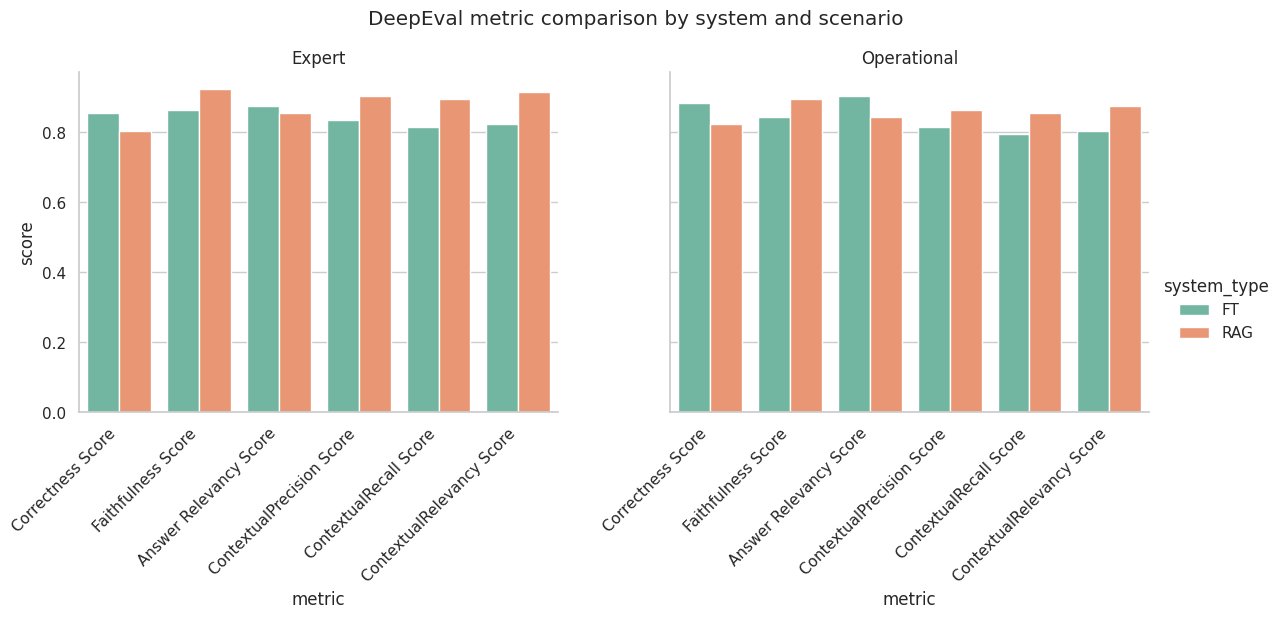

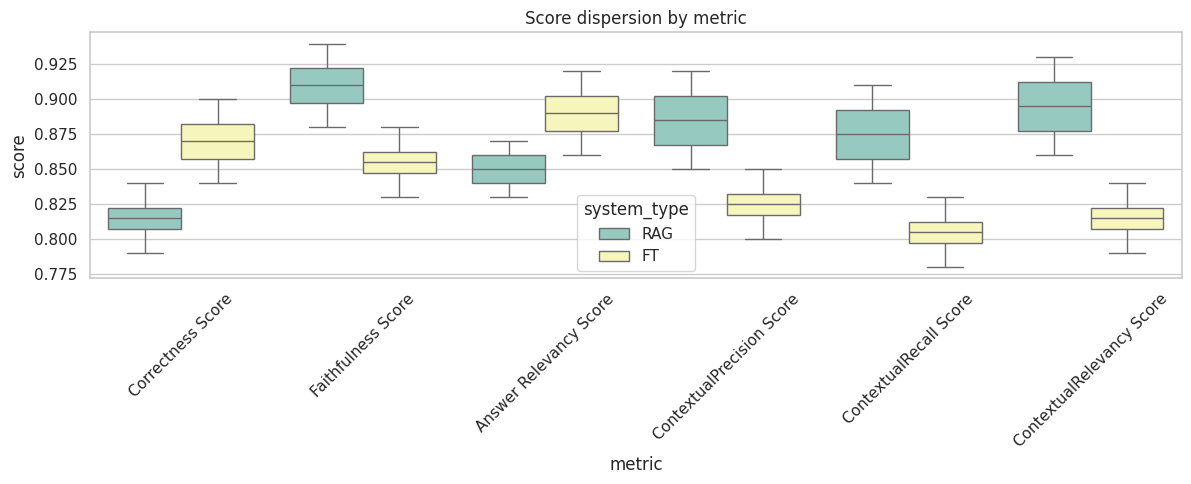

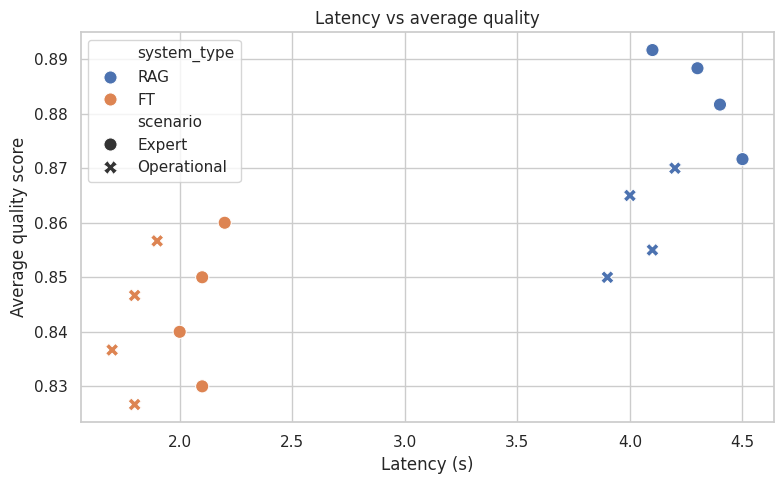

In [6]:
plot_metric_bars(summary_df, metric_columns)
plot_metric_distributions(results_df, metric_columns)
plot_latency_scatter(results_df)

## 6. Comparative analysis

The synthetic pattern below is intentionally designed to show different trade-offs by scenario so the final report can stay nuanced.

### Checklist
- [x] The analysis distinguishes Expert from Operational behavior.
- [x] The analysis compares quality, grounding, and latency together.
- [x] The analysis mentions where FT and RAG win different metrics.
- [x] The story avoids a single universal winner.

In [7]:
analysis_rows = []
for scenario in summary_df["scenario"].unique():
    subset = summary_df[summary_df["scenario"] == scenario]
    rag_row = subset[subset["system_type"] == "RAG"].iloc[0]
    ft_row = subset[subset["system_type"] == "FT"].iloc[0]
    analysis_rows.append({
        "scenario": scenario,
        "better_correctness": "FT" if ft_row["Correctness Score"] > rag_row["Correctness Score"] else "RAG",
        "better_faithfulness": "FT" if ft_row["Faithfulness Score"] > rag_row["Faithfulness Score"] else "RAG",
        "better_latency": "FT" if ft_row["latency_s"] < rag_row["latency_s"] else "RAG",
    })

analysis_df = pd.DataFrame(analysis_rows)
display(analysis_df)

summary_text = []
for _, row in analysis_df.iterrows():
    scenario = row["scenario"]
    better_correctness = row["better_correctness"]
    better_faithfulness = row["better_faithfulness"]
    better_latency = row["better_latency"]
    summary_text.append(
        f"In the {scenario} scenario, {better_correctness} is stronger on correctness, {better_faithfulness} is stronger on faithfulness, and {better_latency} is faster."
    )
display(Markdown("\n\n".join(summary_text)))

,scenario,better_correctness,better_faithfulness,better_latency
0,Expert,FT,RAG,FT
1,Operational,FT,RAG,FT


In the Expert scenario, FT is stronger on correctness, RAG is stronger on faithfulness, and FT is faster.

In the Operational scenario, FT is stronger on correctness, RAG is stronger on faithfulness, and FT is faster.

## 7. Final conclusion

This example shows how the final report should end: with a scenario-level recommendation, a short risk statement, and a note on limitations.

### Checklist
- [x] The conclusion summarizes the main finding per scenario.
- [x] The conclusion references the evidence shown above.
- [x] The conclusion states the limitations of the synthetic example.
- [x] The conclusion ends with a practical recommendation.

### Example conclusion
RAG is the safer choice when the objective is traceability and context-grounded answers in Expert scenarios, while FT is the better operational choice when the priority is speed and concise actionability. The final recommendation is to use FT for fast operational support and keep RAG for complex expert cases where grounding matters more than raw response speed.